In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
df = pd.read_csv("dataset.csv")
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [7]:
print("Quantidade de linhas e colunas:", df.shape)
print("\nColunas do dataset:")
print(df.columns.tolist())

Quantidade de linhas e colunas: (114000, 20)

Colunas do dataset:
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


# 1. Quais são os 10 gêneros musicais com a maior média de popularidade?

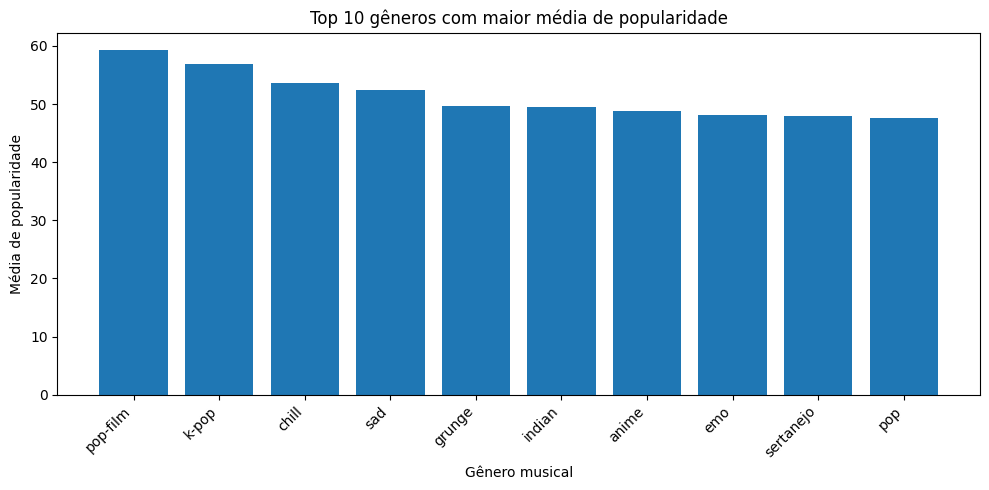

Insight:
O gráfico mostra quais gêneros possuem maior popularidade média dentro da base analisada.
track_genre
pop-film     59.283
k-pop        56.896
chill        53.651
sad          52.379
grunge       49.594
indian       49.539
anime        48.772
emo          48.128
sertanejo    47.866
pop          47.576
Name: popularity, dtype: float64


In [8]:
top_generos = (
    df.groupby("track_genre")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.bar(top_generos.index, top_generos.values)

plt.title("Top 10 gêneros com maior média de popularidade")
plt.xlabel("Gênero musical")
plt.ylabel("Média de popularidade")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

print("Insight:")
print("O gráfico mostra quais gêneros possuem maior popularidade média dentro da base analisada.")
print(top_generos)

# 2. Qual é a distribuição do ritmo das músicas na plataforma? (BPM)

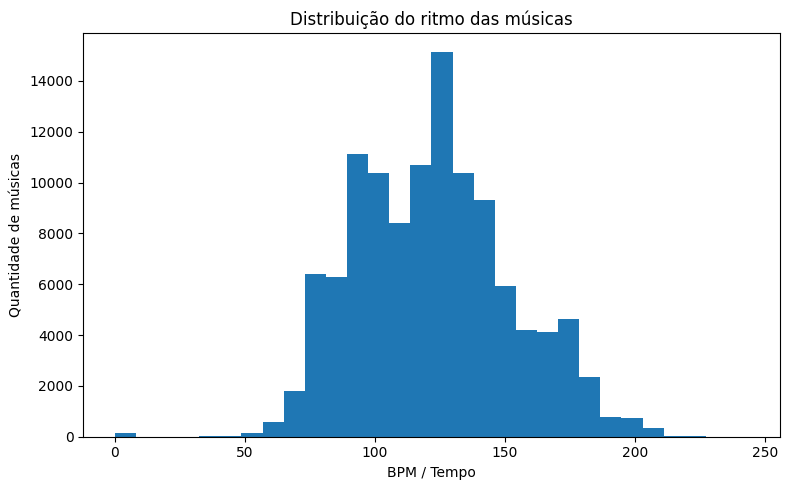

Insight:
A maior concentração de músicas aparece nas faixas de BPM onde as barras são mais altas.
BPM médio: 122.15
BPM mínimo: 0.0
BPM máximo: 243.37


In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df["tempo"].dropna(), bins=30)

plt.title("Distribuição do ritmo das músicas")
plt.xlabel("BPM / Tempo")
plt.ylabel("Quantidade de músicas")

plt.tight_layout()
plt.show()

print("Insight:")
print("A maior concentração de músicas aparece nas faixas de BPM onde as barras são mais altas.")
print("BPM médio:", round(df["tempo"].mean(), 2))
print("BPM mínimo:", round(df["tempo"].min(), 2))
print("BPM máximo:", round(df["tempo"].max(), 2))

# 3. O efeito “show ao vivo”: a experiência live destrói o desempenho no streaming?

/tmp/ipykernel_6919/261446088.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("faixa_liveness")["popularity"]


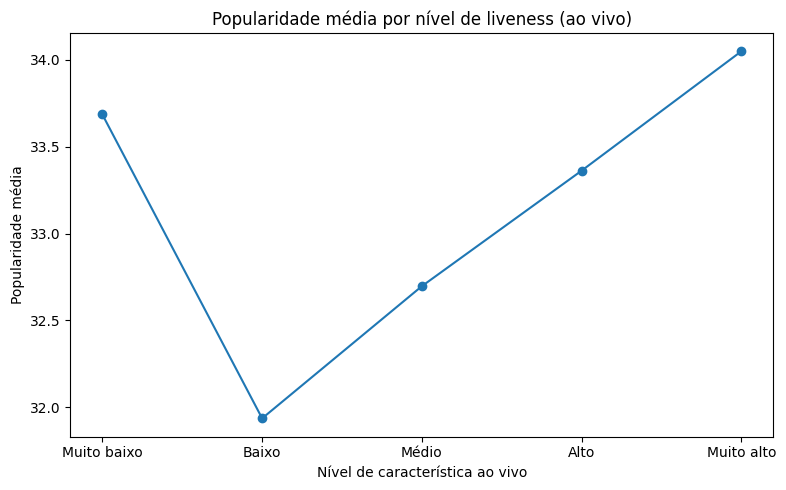

Insight:
Se a linha cai conforme o liveness (ao vivo) aumenta, isso indica que músicas com mais característica ao vivo tendem a ter menor popularidade.
faixa_liveness
Muito baixo    33.685900
Baixo          31.936074
Médio          32.697500
Alto           33.362706
Muito alto     34.050400
Name: popularity, dtype: float64


In [10]:
df["faixa_liveness"] = pd.cut(
    df["liveness"],
    bins=5,
    labels=["Muito baixo", "Baixo", "Médio", "Alto", "Muito alto"]
)

popularidade_liveness = (
    df.groupby("faixa_liveness")["popularity"]
    .mean()
)

plt.figure(figsize=(8, 5))
plt.plot(popularidade_liveness.index, popularidade_liveness.values, marker="o")

plt.title("Popularidade média por nível de liveness (ao vivo)")
plt.xlabel("Nível de característica ao vivo")
plt.ylabel("Popularidade média")

plt.tight_layout()
plt.show()

print("Insight:")
print("Se a linha cai conforme o liveness (ao vivo) aumenta, isso indica que músicas com mais característica ao vivo tendem a ter menor popularidade.")
print(popularidade_liveness)

# 4. Há relação direta entre "loudness" (barulho) e energy?

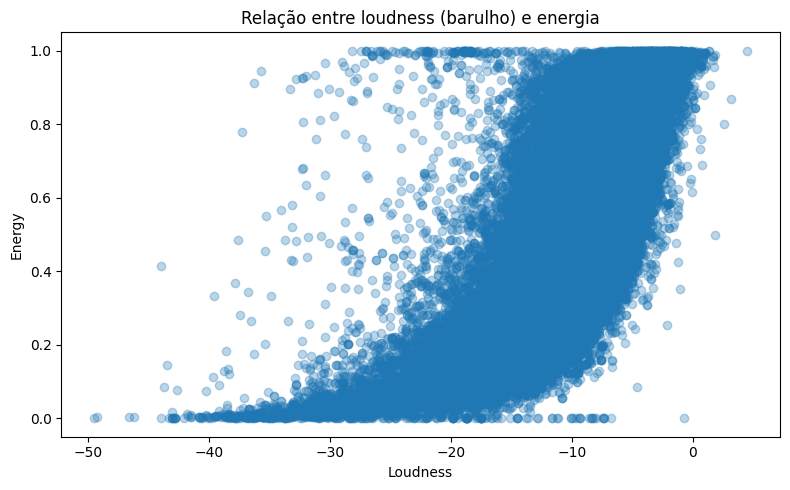

Insight:
Cada ponto representa uma música.
Se os pontos sobem da esquerda para a direita, existe relação positiva entre volume e energia.
Correlação entre loudness e energy: 0.762


In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df["loudness"], df["energy"], alpha=0.3)

plt.title("Relação entre loudness (barulho) e energia")
plt.xlabel("Loudness")
plt.ylabel("Energy")

plt.tight_layout()
plt.show()

correlacao = np.corrcoef(df["loudness"].dropna(), df["energy"].dropna())[0, 1]

print("Insight:")
print("Cada ponto representa uma música.")
print("Se os pontos sobem da esquerda para a direita, existe relação positiva entre volume e energia.")
print("Correlação entre loudness e energy:", round(correlacao, 3))

# 5. Como se comporta a dançabilidade entre músicas explícitas e não explícitas?

/tmp/ipykernel_6919/3386751430.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


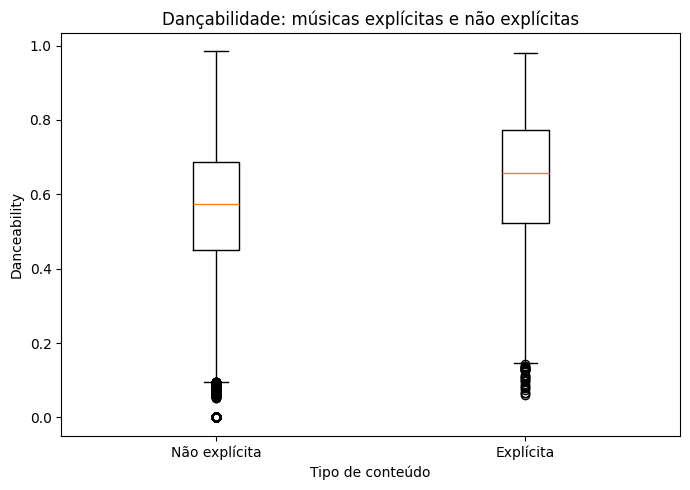

Insight:
O boxplot compara a distribuição da dançabilidade entre músicas explícitas e não explícitas.
Mediana não explícita: 0.574
Mediana explícita: 0.658


In [12]:
df["explicit"] = df["explicit"].astype(str).str.lower().map({
    "true": True,
    "false": False
})

dance_nao_explicit = df[df["explicit"] == False]["danceability"].dropna()
dance_explicit = df[df["explicit"] == True]["danceability"].dropna()

plt.figure(figsize=(7, 5))
plt.boxplot(
    [dance_nao_explicit, dance_explicit],
    labels=["Não explícita", "Explícita"]
)

plt.title("Dançabilidade: músicas explícitas e não explícitas")
plt.xlabel("Tipo de conteúdo")
plt.ylabel("Danceability")

plt.tight_layout()
plt.show()

print("Insight:")
print("O boxplot compara a distribuição da dançabilidade entre músicas explícitas e não explícitas.")
print("Mediana não explícita:", round(dance_nao_explicit.median(), 3))
print("Mediana explícita:", round(dance_explicit.median(), 3))

# 6. Músicas mais energéticas são mais populares?

/tmp/ipykernel_6919/2907173239.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("faixa_energy")["popularity"]


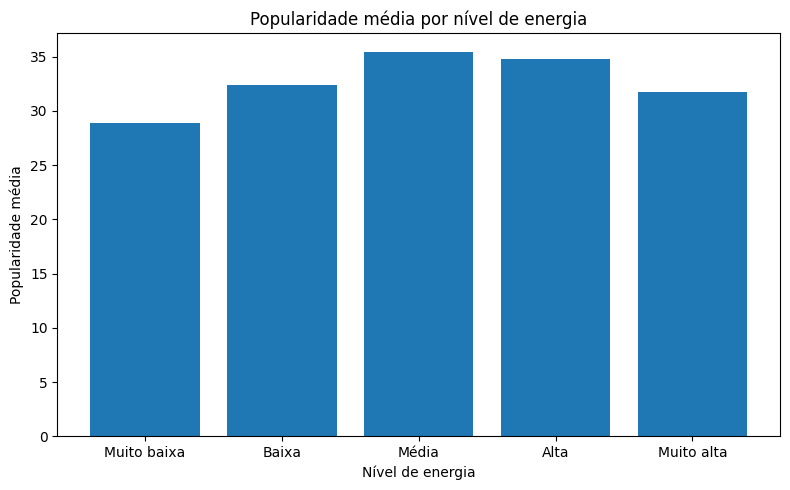

Insight:
Esse gráfico mostra se músicas com maior energia também apresentam maior popularidade média.
faixa_energy
Muito baixa    28.897130
Baixa          32.358625
Média          35.431890
Alta           34.820456
Muito alta     31.786589
Name: popularity, dtype: float64


In [13]:
df["faixa_energy"] = pd.cut(
    df["energy"],
    bins=5,
    labels=["Muito baixa", "Baixa", "Média", "Alta", "Muito alta"]
)

popularidade_energy = (
    df.groupby("faixa_energy")["popularity"]
    .mean()
)

plt.figure(figsize=(8, 5))
plt.bar(popularidade_energy.index, popularidade_energy.values)

plt.title("Popularidade média por nível de energia")
plt.xlabel("Nível de energia")
plt.ylabel("Popularidade média")

plt.tight_layout()
plt.show()

print("Insight:")
print("Esse gráfico mostra se músicas com maior energia também apresentam maior popularidade média.")
print(popularidade_energy)

# 7. O "Efeito TikTok": Músicas mais curtas são mais populares na era do streaming?

/tmp/ipykernel_6922/389109853.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("faixa_duracao")["popularity"]


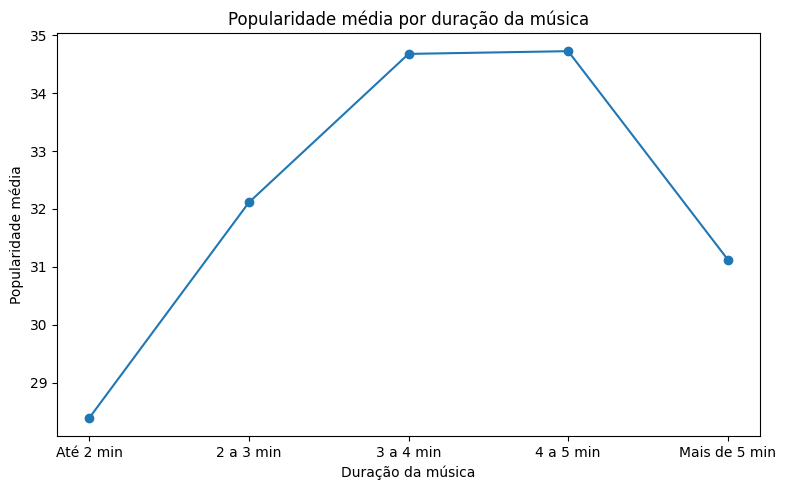

Insight:
Esse gráfico ajuda a observar se músicas mais curtas têm maior popularidade média.
Se as faixas menores tiverem valores mais altos, pode indicar um efeito ligado ao consumo rápido em plataformas digitais.
faixa_duracao
Até 2 min        28.394507
2 a 3 min        32.113904
3 a 4 min        34.677001
4 a 5 min        34.724115
Mais de 5 min    31.128235
Name: popularity, dtype: float64


In [11]:
df["duration_min"] = df["duration_ms"] / 60000

df["faixa_duracao"] = pd.cut(
    df["duration_min"],
    bins=[0, 2, 3, 4, 5, 20],
    labels=[
        "Até 2 min",
        "2 a 3 min",
        "3 a 4 min",
        "4 a 5 min",
        "Mais de 5 min"
    ]
)

popularidade_duracao = (
    df.groupby("faixa_duracao")["popularity"]
    .mean()
)

plt.figure(figsize=(8, 5))
plt.plot(popularidade_duracao.index, popularidade_duracao.values, marker="o")

plt.title("Popularidade média por duração da música")
plt.xlabel("Duração da música")
plt.ylabel("Popularidade média")

plt.tight_layout()
plt.show()

print("Insight:")
print("Esse gráfico ajuda a observar se músicas mais curtas têm maior popularidade média.")
print("Se as faixas menores tiverem valores mais altos, pode indicar um efeito ligado ao consumo rápido em plataformas digitais.")
print(popularidade_duracao)

# 8. O Paradoxo da Acústica: O que acontece com a Energia quando os instrumentos são acústicos?

/tmp/ipykernel_6919/3261392104.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("faixa_acousticness")["energy"]


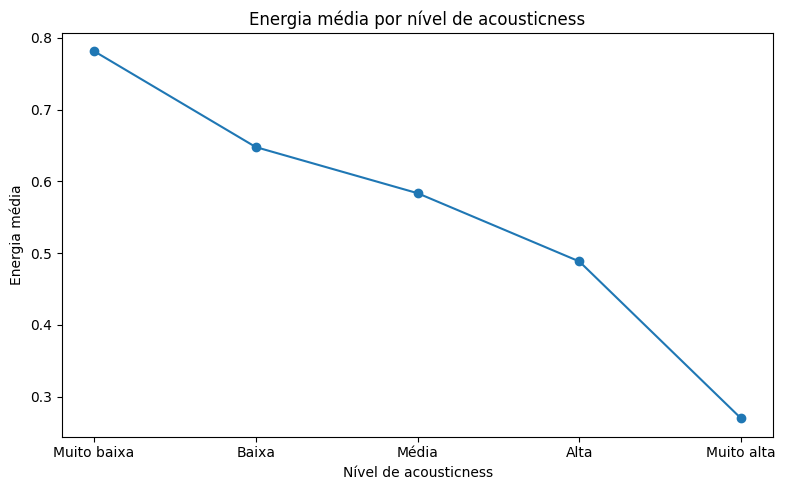

Insight:
Esse gráfico mostra como a energia média muda conforme aumenta o nível de acousticness.
Se a linha cair, isso indica que músicas mais acústicas tendem a ter menor energia.
Se a linha subir ou ficar estável, pode indicar que músicas acústicas também conseguem manter energia alta.
faixa_acousticness
Muito baixa    0.781580
Baixa          0.647905
Média          0.583663
Alta           0.488556
Muito alta     0.269819
Name: energy, dtype: float64


In [14]:

df["faixa_acousticness"] = pd.cut(
    df["acousticness"],
    bins=5,
    labels=[
        "Muito baixa",
        "Baixa",
        "Média",
        "Alta",
        "Muito alta"
    ]
)

energia_acustica = (
    df.groupby("faixa_acousticness")["energy"]
    .mean()
)
plt.figure(figsize=(8, 5))
plt.plot(energia_acustica.index, energia_acustica.values, marker="o")

plt.title("Energia média por nível de acousticness")
plt.xlabel("Nível de acousticness")
plt.ylabel("Energia média")

plt.tight_layout()
plt.show()

print("Insight:")
print("Esse gráfico mostra como a energia média muda conforme aumenta o nível de acousticness.")
print("Se a linha cair, isso indica que músicas mais acústicas tendem a ter menor energia.")
print("Se a linha subir ou ficar estável, pode indicar que músicas acústicas também conseguem manter energia alta.")
print(energia_acustica)